# Online Retail EDA
## Sales Patterns, Customer Behavior, and Cancellations

This notebook explores historical online retail transactions using Python.

The analysis will assess data quality, investigate sales and customer
patterns, examine cancellations and unusual transactions, and summarize
business implications.

Source: UCI Machine Learning Repository — Online Retail
https://archive.ics.uci.edu/dataset/352/online+retail

Creator: Daqing Chen
License: CC BY 4.0

## 1. Load and Inspect the Original Data

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [3]:
# Use the uploaded filename.
filename = next(iter(uploaded))

# Inspect the workbook's sheets.
excel_file = pd.ExcelFile(filename)
print("WORKSHEET NAMES")
print(excel_file.sheet_names)

# Load the first sheet without modifying the original records.
# Identifiers are labels, so preserve them as text.
raw_df = pd.read_excel(
    excel_file,
    sheet_name=0,
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "CustomerID": "string"
    }
)

print("\nDATASET SIZE")
print("Rows:", len(raw_df))
print("Columns:", len(raw_df.columns))

print("\nCOLUMN NAMES")
for column in raw_df.columns:
    print(column)

print("\nDATA TYPES")
print(raw_df.dtypes)

print("\nMISSING VALUES BY COLUMN")
print(raw_df.isna().sum())

print("\nFIRST FIVE ROWS")
display(raw_df.head())

WORKSHEET NAMES
['Online Retail']

DATASET SIZE
Rows: 541909
Columns: 8

COLUMN NAMES
InvoiceNo
StockCode
Description
Quantity
InvoiceDate
UnitPrice
CustomerID
Country

DATA TYPES
InvoiceNo      string[python]
StockCode      string[python]
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID     string[python]
Country                object
dtype: object

MISSING VALUES BY COLUMN
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

FIRST FIVE ROWS


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 2. Data Quality Assessment

Check repeated records, cancellation indicators, numeric values,
date coverage, and country categories before choosing cleaning rules.

In [4]:
# These checks inspect raw_df without changing it.

print("EXACT DUPLICATE CHECK")
print(
    "Repeated rows beyond the first occurrence:",
    raw_df.duplicated().sum()
)

print("\nIDENTIFIER COUNTS")
print("Distinct invoice numbers:", raw_df["InvoiceNo"].nunique())
print("Distinct product codes:", raw_df["StockCode"].nunique())
print(
    "Distinct recorded customer IDs:",
    raw_df["CustomerID"].nunique()
)

# Treat the cancellation prefix case-insensitively.
cancellation_flag = (
    raw_df["InvoiceNo"]
    .str.upper()
    .str.startswith("C", na=False)
)

print("\nCANCELLATION AND NUMERIC CHECKS")
print("Cancellation-prefixed rows:", cancellation_flag.sum())
print("Negative quantities:", raw_df["Quantity"].lt(0).sum())
print("Zero quantities:", raw_df["Quantity"].eq(0).sum())
print("Negative unit prices:", raw_df["UnitPrice"].lt(0).sum())
print("Zero unit prices:", raw_df["UnitPrice"].eq(0).sum())

print(
    "Negative quantities without cancellation prefix:",
    (
        raw_df["Quantity"].lt(0)
        & ~cancellation_flag
    ).sum()
)

print(
    "Cancellation-prefixed rows without negative quantity:",
    (
        cancellation_flag
        & raw_df["Quantity"].ge(0)
    ).sum()
)

print("\nNUMERIC DISTRIBUTIONS")
display(
    raw_df[["Quantity", "UnitPrice"]].describe(
        percentiles=[0.01, 0.5, 0.95, 0.99]
    )
)

print("\nDATE COVERAGE")
print("Earliest transaction:", raw_df["InvoiceDate"].min())
print("Latest transaction:", raw_df["InvoiceDate"].max())
print("Missing transaction dates:", raw_df["InvoiceDate"].isna().sum())

print("\nTOP 10 COUNTRIES BY LINE-ITEM COUNT")
display(raw_df["Country"].value_counts().head(10))

EXACT DUPLICATE CHECK
Repeated rows beyond the first occurrence: 5268

IDENTIFIER COUNTS
Distinct invoice numbers: 25900
Distinct product codes: 4070
Distinct recorded customer IDs: 4372

CANCELLATION AND NUMERIC CHECKS
Cancellation-prefixed rows: 9288
Negative quantities: 10624
Zero quantities: 0
Negative unit prices: 2
Zero unit prices: 2515
Negative quantities without cancellation prefix: 1336
Cancellation-prefixed rows without negative quantity: 0

NUMERIC DISTRIBUTIONS


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
1%,-2.000000,0.190000
50%,3.000000,2.080000
95%,29.000000,9.950000
99%,100.000000,18.000000
max,80995.000000,38970.000000



DATE COVERAGE
Earliest transaction: 2010-12-01 08:26:00
Latest transaction: 2011-12-09 12:50:00
Missing transaction dates: 0

TOP 10 COUNTRIES BY LINE-ITEM COUNT


,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


### Inspect Unusual Records

Review nonpositive prices, negative quantities without cancellation
prefixes, and large positive transaction values before defining
analysis inclusion rules.

In [5]:
# Create a temporary inspection copy.
# raw_df remains unchanged.

inspection_df = raw_df.copy()

inspection_df["is_cancellation"] = (
    inspection_df["InvoiceNo"]
    .str.upper()
    .str.startswith("C", na=False)
)

inspection_df["line_value"] = (
    inspection_df["Quantity"] * inspection_df["UnitPrice"]
)

columns_to_show = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "UnitPrice",
    "line_value",
    "CustomerID",
    "InvoiceDate"
]

print("1. NEGATIVE-PRICE RECORDS")
display(
    inspection_df.loc[
        inspection_df["UnitPrice"] < 0,
        columns_to_show
    ]
)

print("\n2. SAMPLE OF ZERO-PRICE RECORDS")
display(
    inspection_df.loc[
        inspection_df["UnitPrice"] == 0,
        columns_to_show
    ].head(8)
)

print("\n3. NEGATIVE QUANTITIES WITHOUT CANCELLATION PREFIX")
display(
    inspection_df.loc[
        (inspection_df["Quantity"] < 0)
        & (~inspection_df["is_cancellation"]),
        columns_to_show
    ].head(8)
)

print("\n4. LARGEST POSITIVE LINE VALUES")
positive_sales_mask = (
    (~inspection_df["is_cancellation"])
    & (inspection_df["Quantity"] > 0)
    & (inspection_df["UnitPrice"] > 0)
)

display(
    inspection_df.loc[
        positive_sales_mask,
        columns_to_show
    ]
    .nlargest(5, "line_value")
)

1. NEGATIVE-PRICE RECORDS


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_value,CustomerID,InvoiceDate
299983,A563186,B,Adjust bad debt,1,-11062.06,-11062.06,<NA>,2011-08-12 14:51:00
299984,A563187,B,Adjust bad debt,1,-11062.06,-11062.06,<NA>,2011-08-12 14:52:00



2. SAMPLE OF ZERO-PRICE RECORDS


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_value,CustomerID,InvoiceDate
622,536414,22139,NaN,56,0.0,0.0,<NA>,2010-12-01 11:52:00
1970,536545,21134,NaN,1,0.0,0.0,<NA>,2010-12-01 14:32:00
1971,536546,22145,NaN,1,0.0,0.0,<NA>,2010-12-01 14:33:00
1972,536547,37509,NaN,1,0.0,0.0,<NA>,2010-12-01 14:33:00
1987,536549,85226A,NaN,1,0.0,0.0,<NA>,2010-12-01 14:34:00
1988,536550,85044,NaN,1,0.0,0.0,<NA>,2010-12-01 14:34:00
2024,536552,20950,NaN,1,0.0,0.0,<NA>,2010-12-01 14:34:00
2025,536553,37461,NaN,3,0.0,0.0,<NA>,2010-12-01 14:35:00



3. NEGATIVE QUANTITIES WITHOUT CANCELLATION PREFIX


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_value,CustomerID,InvoiceDate
2406,536589,21777,NaN,-10,0.0,-0.0,<NA>,2010-12-01 16:50:00
4347,536764,84952C,NaN,-38,0.0,-0.0,<NA>,2010-12-02 14:42:00
7188,536996,22712,NaN,-20,0.0,-0.0,<NA>,2010-12-03 15:30:00
7189,536997,22028,NaN,-20,0.0,-0.0,<NA>,2010-12-03 15:30:00
7190,536998,85067,NaN,-6,0.0,-0.0,<NA>,2010-12-03 15:30:00
7192,537000,21414,NaN,-22,0.0,-0.0,<NA>,2010-12-03 15:32:00
7193,537001,21653,NaN,-6,0.0,-0.0,<NA>,2010-12-03 15:33:00
7195,537003,85126,NaN,-2,0.0,-0.0,<NA>,2010-12-03 15:33:00



4. LARGEST POSITIVE LINE VALUES


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_value,CustomerID,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446,2011-12-09 09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346,2011-01-18 10:01:00
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098,2011-06-10 15:28:00
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,<NA>,2010-12-07 15:08:00
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,<NA>,2011-08-12 14:50:00


### Investigate Special Codes and Large Transactions

Identify codes requiring review and inspect potential cancellations
associated with the two largest positive product transactions.

In [6]:
# A screening rule based on the source's product-code description.
# Nonmatching codes require review; this does not prove they are invalid.

codes = inspection_df["StockCode"].str.strip()

standard_code_pattern = codes.str.fullmatch(
    r"\d{5}[A-Za-z]?",
    na=False
)

special_code_summary = (
    inspection_df.loc[~standard_code_pattern]
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        line_count=("InvoiceNo", "size"),
        recorded_line_value=("line_value", "sum")
    )
    .reset_index()
    .sort_values("line_count", ascending=False)
)

print("1. PRODUCT CODES REQUIRING REVIEW")
print("Distinct codes:", special_code_summary["StockCode"].nunique())
display(special_code_summary.head(30))

# Inspect both positive and negative versions of the two
# largest product quantities, retaining customer and timestamp details.

large_transaction_mask = (
    (
        inspection_df["StockCode"].eq("23843")
        & inspection_df["Quantity"].abs().eq(80995)
    )
    |
    (
        inspection_df["StockCode"].eq("23166")
        & inspection_df["Quantity"].abs().eq(74215)
    )
)

print("\n2. LARGE TRANSACTIONS AND POSSIBLE CANCELLATION COUNTERPARTS")
display(
    inspection_df.loc[
        large_transaction_mask,
        columns_to_show + ["is_cancellation"]
    ].sort_values(["StockCode", "InvoiceDate"])
)

1. PRODUCT CODES REQUIRING REVIEW
Distinct codes: 37


,StockCode,Description,line_count,recorded_line_value
34,POST,POSTAGE,1252,66230.640
30,DOT,DOTCOM POSTAGE,709,206245.480
32,M,Manual,571,-68674.190
0,15056BL,EDWARDIAN PARASOL BLACK,326,15176.340
7,C2,CARRIAGE,143,6986.000
10,D,Discount,77,-5696.220
36,S,SAMPLES,63,-3049.390
1,15056bl,EDWARDIAN PARASOL BLACK,62,1086.880
6,BANK CHARGES,Bank Charges,37,-7175.639
4,AMAZONFEE,AMAZON FEE,34,-221520.500



2. LARGE TRANSACTIONS AND POSSIBLE CANCELLATION COUNTERPARTS


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,line_value,CustomerID,InvoiceDate,is_cancellation
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.6,12346,2011-01-18 10:01:00,False
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,-77183.6,12346,2011-01-18 10:17:00,True
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.6,16446,2011-12-09 09:15:00,False
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,-168469.6,16446,2011-12-09 09:27:00,True


## 3. Prepare Analysis Datasets

All original records will be retained in a separate prepared dataset.

Preparation rules:
- Flag exact repeated rows without automatically removing them.
- Separate merchandise candidates from postage, fees, accounting
  adjustments, discounts, samples, vouchers, and unresolved codes.
- Define positive merchandise sales using positive quantity and price
  and an invoice without a cancellation prefix.
- Analyze eligible merchandise cancellation records separately.
- Retain missing customer IDs for eligible merchandise analysis,
  but exclude them from customer-level analysis.
- Retain and flag the two large transactions and their cancellation
  counterparts for sensitivity analysis.

Positive sales value describes recorded positive merchandise entries.
It does not deduct cancellations and is not profit or confirmed revenue.

In [7]:
# Preserve raw_df and all original columns.
prepared_df = raw_df.copy()

# Flag exact repetitions using the original eight columns.
prepared_df["is_repeat_row"] = raw_df.duplicated(keep="first")

# Standardize codes temporarily for classification.
# Original StockCode values remain unchanged.
code_for_review = (
    prepared_df["StockCode"].str.strip().str.upper()
)

invoice_for_review = (
    prepared_df["InvoiceNo"].str.strip().str.upper()
)

prepared_df["is_cancellation"] = (
    invoice_for_review.str.startswith("C", na=False)
)

prepared_df["line_value"] = (
    prepared_df["Quantity"] * prepared_df["UnitPrice"]
)

prepared_df["missing_customer_id"] = (
    prepared_df["CustomerID"].isna()
    | prepared_df["CustomerID"].str.strip().eq("").fillna(False)
)

prepared_df["missing_description"] = (
    prepared_df["Description"].isna()
    | prepared_df["Description"]
        .astype("string").str.strip().eq("").fillna(False)
)

# Explicit special codes identified during inspection.
special_codes = {
    "POST", "DOT", "C2", "M", "D", "S",
    "BANK CHARGES", "AMAZONFEE", "CRUK", "B"
}

is_special = (
    code_for_review.isin(special_codes)
    | code_for_review.str.startswith("GIFT_", na=False)
)

# Broader merchandise pattern allows multiple trailing letters,
# including the inspected product code 15056BL.
numeric_product_pattern = code_for_review.str.fullmatch(
    r"\d{5}[A-Z]*",
    na=False
)

# Additional merchandise codes supported by inspected descriptions.
reviewed_product_codes = {
    "DCGSSGIRL", "DCGSSBOY", "DCGS0003",
    "DCGS0004", "DCGS0076", "PADS"
}

is_merchandise_candidate = (
    numeric_product_pattern
    | code_for_review.isin(reviewed_product_codes)
) & ~is_special

prepared_df["code_category"] = "Unresolved"
prepared_df.loc[is_special, "code_category"] = "Special / non-merchandise"
prepared_df.loc[
    is_merchandise_candidate, "code_category"
] = "Merchandise candidate"

# Eligibility rules for separate analyses.
prepared_df["eligible_positive_sale"] = (
    is_merchandise_candidate
    & ~prepared_df["is_cancellation"]
    & prepared_df["Quantity"].gt(0)
    & prepared_df["UnitPrice"].gt(0)
)

prepared_df["eligible_merchandise_cancellation"] = (
    is_merchandise_candidate
    & prepared_df["is_cancellation"]
    & prepared_df["Quantity"].lt(0)
    & prepared_df["UnitPrice"].gt(0)
)

# Flag the four inspected records for later sensitivity analysis.
large_case_indices = inspection_df.index[large_transaction_mask]

prepared_df["is_large_reversal_case"] = (
    prepared_df.index.isin(large_case_indices)
)

# Create analysis subsets without deleting records from prepared_df.
positive_sales_df = prepared_df.loc[
    prepared_df["eligible_positive_sale"]
].copy()

merchandise_cancellations_df = prepared_df.loc[
    prepared_df["eligible_merchandise_cancellation"]
].copy()

customer_sales_df = positive_sales_df.loc[
    ~positive_sales_df["missing_customer_id"]
].copy()

# Validation and subset counts.
print("PREPARATION CHECKS")
print("Original rows:", len(raw_df))
print("Prepared rows:", len(prepared_df))
print("Flagged repeated rows:", prepared_df["is_repeat_row"].sum())
print("Cancellation-prefixed rows:", prepared_df["is_cancellation"].sum())
print("Flagged large-case rows:", prepared_df["is_large_reversal_case"].sum())

large_case_value = prepared_df.loc[
    prepared_df["is_large_reversal_case"], "line_value"
].sum()

print("Signed value of large cases (£):", round(large_case_value, 2))

print("\nANALYSIS SUBSET COUNTS")
print("Positive merchandise lines:", len(positive_sales_df))
print("Merchandise cancellation lines:", len(merchandise_cancellations_df))
print("Positive lines with customer IDs:", len(customer_sales_df))

print("\nCODE CATEGORY COUNTS")
display(prepared_df["code_category"].value_counts())

print("\nUNRESOLVED CODES")
display(
    prepared_df.loc[
        prepared_df["code_category"].eq("Unresolved"),
        ["StockCode", "Description"]
    ].drop_duplicates()
)

PREPARATION CHECKS
Original rows: 541909
Prepared rows: 541909
Flagged repeated rows: 5268
Cancellation-prefixed rows: 9288
Flagged large-case rows: 4
Signed value of large cases (£): 0.0

ANALYSIS SUBSET COUNTS
Positive merchandise lines: 527759
Merchandise cancellation lines: 8704
Positive lines with customer IDs: 396340

CODE CATEGORY COUNTS


,count
code_category,
Merchandise candidate,538950
Special / non-merchandise,2946
Unresolved,13



UNRESOLVED CODES


,StockCode,Description
40052,DCGS0070,CAMOUFLAGE DOG COLLAR
74825,DCGS0055,NaN
74838,DCGS0072,NaN
74839,DCGS0074,NaN
75053,DCGS0069,OOH LA LA DOGS COLLAR
75295,DCGS0057,NaN
279251,DCGS0073,ebay
279252,DCGS0071,NaN
279253,DCGS0070,NaN
279254,DCGS0069,ebay


## 4. Exploratory Analysis
### Analysis 1: Merchandise Transaction Baseline

Summarize eligible positive merchandise entries and cancellation
entries. Counts represent invoice lines unless explicitly labeled
as distinct invoices or customers.

Exact repetitions remain included. Positive merchandise value
includes the large transactions investigated earlier.

In [8]:
positive_value = positive_sales_df["line_value"].sum()

cancellation_value = (
    merchandise_cancellations_df["line_value"].sum()
)

summary = pd.DataFrame({
    "metric": [
        "Positive merchandise lines",
        "Distinct invoices with eligible positive merchandise",
        "Identified customers with eligible positive merchandise",
        "Positive merchandise value (£)",
        "Merchandise cancellation magnitude (£)",
        "Signed merchandise value after cancellations (£)"
    ],
    "value": [
        len(positive_sales_df),
        positive_sales_df["InvoiceNo"].nunique(),
        customer_sales_df["CustomerID"].nunique(),
        round(positive_value, 2),
        round(abs(cancellation_value), 2),
        round(positive_value + cancellation_value, 2)
    ]
})

display(summary)

print("\nPOSITIVE MERCHANDISE LINE DISTRIBUTIONS")
display(
    positive_sales_df[
        ["Quantity", "UnitPrice", "line_value"]
    ].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
)

,metric,value
0,Positive merchandise lines,527759.00
1,Distinct invoices with eligible positive merch...,19773.00
2,Identified customers with eligible positive me...,4334.00
3,Positive merchandise value (£),10271404.55
4,Merchandise cancellation magnitude (£),478724.18
5,Signed merchandise value after cancellations (£),9792680.37



POSITIVE MERCHANDISE LINE DISTRIBUTIONS


,Quantity,UnitPrice,line_value
count,527759.000000,527759.000000,527759.000000
mean,10.567515,3.265363,19.462301
std,155.834269,4.377894,268.605445
min,1.000000,0.001000,0.001000
50%,3.000000,2.080000,9.900000
90%,24.000000,7.620000,31.600000
95%,30.000000,9.950000,58.500000
99%,100.000000,16.630000,179.000000
max,80995.000000,649.500000,168469.600000


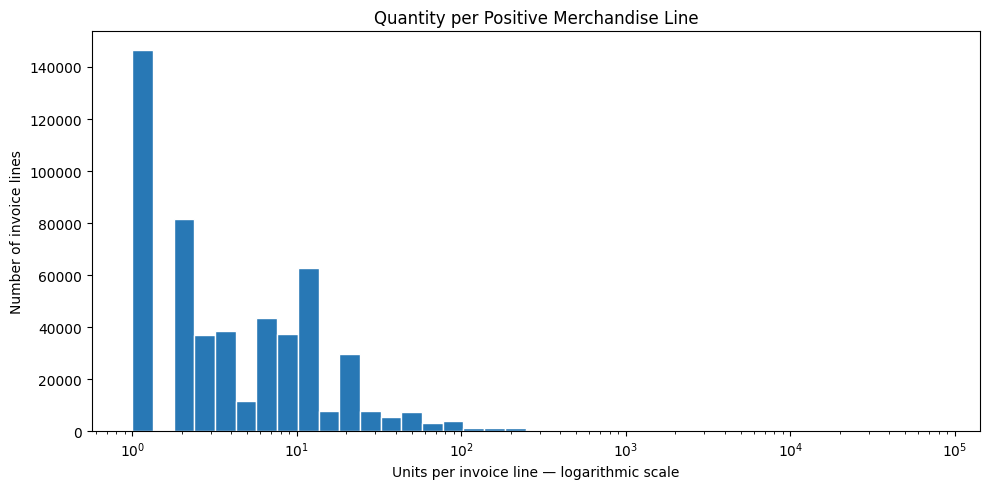

In [9]:
import numpy as np
import matplotlib.pyplot as plt

quantities = positive_sales_df["Quantity"]

# Log-spaced bins reveal the full range without removing large values.
bins = np.geomspace(
    quantities.min(),
    quantities.max(),
    40
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    quantities,
    bins=bins,
    color="#2878B5",
    edgecolor="white"
)

ax.set_xscale("log")
ax.set_title("Quantity per Positive Merchandise Line")
ax.set_xlabel("Units per invoice line — logarithmic scale")
ax.set_ylabel("Number of invoice lines")

fig.tight_layout()
plt.show()

In [10]:
# Save the chart created in the preceding cell.
chart_filename = "01_quantity_distribution.png"

fig.savefig(
    chart_filename,
    dpi=300,
    bbox_inches="tight"
)

from google.colab import files
files.download(chart_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Analysis 2: Sensitivity to Repeated Rows and Large Reversed Transactions

Compare four scenarios:
1. Baseline: retain all eligible records.
2. Exclude exact repetitions after their first occurrence.
3. Exclude the two large positive transactions and their cancellation counterparts.
4. Apply both exclusions.

These exclusions are sensitivity tests. They do not establish that
repeated records or large transactions are errors.

In [11]:
# Each scenario uses the same merchandise eligibility rules.
# Only the inclusion of repeated rows and large cases changes.

scenarios = {
    "Baseline": prepared_df,
    "Without repeated rows": prepared_df.loc[
        ~prepared_df["is_repeat_row"]
    ],
    "Without large reversal cases": prepared_df.loc[
        ~prepared_df["is_large_reversal_case"]
    ],
    "Without both": prepared_df.loc[
        ~prepared_df["is_repeat_row"]
        & ~prepared_df["is_large_reversal_case"]
    ]
}

results = []

for scenario_name, scenario_df in scenarios.items():

    sales = scenario_df.loc[
        scenario_df["eligible_positive_sale"]
    ]

    cancellations = scenario_df.loc[
        scenario_df["eligible_merchandise_cancellation"]
    ]

    positive_value = sales["line_value"].sum()
    cancellation_value = cancellations["line_value"].sum()

    results.append({
        "scenario": scenario_name,
        "positive_lines": len(sales),
        "cancellation_lines": len(cancellations),
        "positive_value_gbp": positive_value,
        "cancellation_magnitude_gbp": abs(cancellation_value),
        "signed_value_gbp": positive_value + cancellation_value
    })

sensitivity_summary = pd.DataFrame(results)

baseline_positive = sensitivity_summary.loc[
    0, "positive_value_gbp"
]

baseline_signed = sensitivity_summary.loc[
    0, "signed_value_gbp"
]

sensitivity_summary["positive_change_percent"] = (
    100
    * (
        sensitivity_summary["positive_value_gbp"]
        - baseline_positive
    )
    / baseline_positive
)

sensitivity_summary["signed_change_percent"] = (
    100
    * (
        sensitivity_summary["signed_value_gbp"]
        - baseline_signed
    )
    / baseline_signed
)

# Round only for display; calculations retain their precision.
display(sensitivity_summary.round(2))

,scenario,positive_lines,cancellation_lines,positive_value_gbp,cancellation_magnitude_gbp,signed_value_gbp,positive_change_percent,signed_change_percent
0,Baseline,527759,8704,10271404.55,478724.18,9792680.37,0.00,0.00
1,Without repeated rows,522538,8668,10247190.81,475901.16,9771289.65,-0.24,-0.22
2,Without large reversal cases,527757,8702,10025751.35,233070.98,9792680.37,-2.39,-0.00
3,Without both,522536,8666,10001537.61,230247.96,9771289.65,-2.63,-0.22


#### Analysis Decision

Retain baseline eligible records for the main analyses because the
available data does not establish that exact repetitions are errors.

Report positive merchandise value, cancellation magnitude, and
signed merchandise value with explicit labels.

The tested exclusions changed the overall signed total by at most
0.22%. This does not establish stability of product rankings,
customer behavior, or other subgroup findings; assess those separately
where relevant.

### Analysis 3: Monthly Merchandise Patterns

Explore monthly positive merchandise value, cancellation magnitude,
signed merchandise value, and positive invoice counts.

Retain baseline eligible records. Identify months whose calendar
boundaries extend beyond the dataset's reporting window.

December 2011 is incomplete and will not be used for a full-month
growth comparison. Observed patterns do not establish recurring
annual seasonality.

In [12]:
# Work with copies so existing datasets remain unchanged.
monthly_sales = positive_sales_df.copy()
monthly_cancellations = merchandise_cancellations_df.copy()

monthly_sales["month"] = (
    monthly_sales["InvoiceDate"].dt.to_period("M")
)

monthly_cancellations["month"] = (
    monthly_cancellations["InvoiceDate"].dt.to_period("M")
)

sales_by_month = monthly_sales.groupby("month").agg(
    positive_lines=("InvoiceNo", "size"),
    positive_invoices=("InvoiceNo", "nunique"),
    positive_value_gbp=("line_value", "sum")
)

cancellations_by_month = monthly_cancellations.groupby("month").agg(
    cancellation_lines=("InvoiceNo", "size"),
    signed_cancellation_value_gbp=("line_value", "sum")
)

# Include every month in the source reporting window.
first_date = raw_df["InvoiceDate"].min().normalize()
last_date = raw_df["InvoiceDate"].max().normalize()

all_months = pd.period_range(
    first_date.to_period("M"),
    last_date.to_period("M"),
    freq="M"
)

monthly_summary = (
    sales_by_month
    .join(cancellations_by_month, how="outer")
    .reindex(all_months)
    .fillna(0)
)

monthly_summary.index.name = "month"

monthly_summary["cancellation_magnitude_gbp"] = (
    -monthly_summary["signed_cancellation_value_gbp"]
)

monthly_summary["signed_value_gbp"] = (
    monthly_summary["positive_value_gbp"]
    + monthly_summary["signed_cancellation_value_gbp"]
)

# Coverage refers to calendar dates, not verified operating days.
monthly_summary["full_month_in_reporting_window"] = [
    (
        month.start_time.normalize() >= first_date
        and month.end_time.normalize() <= last_date
    )
    for month in monthly_summary.index
]

count_columns = [
    "positive_lines",
    "positive_invoices",
    "cancellation_lines"
]

monthly_summary[count_columns] = (
    monthly_summary[count_columns].astype(int)
)

display(
    monthly_summary[
        [
            "positive_lines",
            "positive_invoices",
            "positive_value_gbp",
            "cancellation_magnitude_gbp",
            "signed_value_gbp",
            "full_month_in_reporting_window"
        ]
    ].round(2)
)

print("\nRECONCILIATION CHECKS")
print("Positive lines:", monthly_summary["positive_lines"].sum())
print(
    "Positive merchandise value (£):",
    round(monthly_summary["positive_value_gbp"].sum(), 2)
)
print(
    "Cancellation magnitude (£):",
    round(monthly_summary["cancellation_magnitude_gbp"].sum(), 2)
)
print(
    "Signed merchandise value (£):",
    round(monthly_summary["signed_value_gbp"].sum(), 2)
)

,positive_lines,positive_invoices,positive_value_gbp,cancellation_magnitude_gbp,signed_value_gbp,full_month_in_reporting_window
month,,,,,,
2010-12,41314,1550,777919.05,17607.86,760311.19,True
2011-01,34147,1081,671917.40,91526.30,580391.10,True
2011-02,26964,1093,508886.20,8375.87,500510.33,True
2011-03,35607,1440,691257.61,10675.30,680582.31,True
2011-04,28957,1235,516218.12,33316.91,482901.21,True
2011-05,35979,1668,741192.41,8948.23,732244.18,True
2011-06,35773,1525,738751.87,13760.84,724991.03,True
2011-07,38444,1452,689364.41,11409.21,677955.20,True
2011-08,34326,1339,725513.50,22929.52,702583.98,True



RECONCILIATION CHECKS
Positive lines: 527759
Positive merchandise value (£): 10271404.55
Cancellation magnitude (£): 478724.18
Signed merchandise value (£): 9792680.37


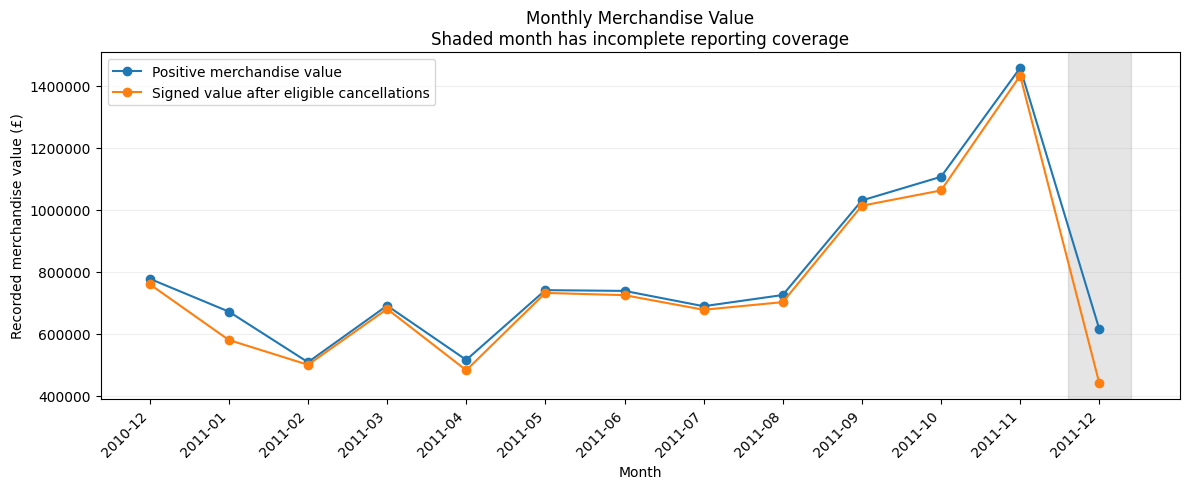

In [13]:
fig_monthly, ax = plt.subplots(figsize=(12, 5))

x_positions = np.arange(len(monthly_summary))

ax.plot(
    x_positions,
    monthly_summary["positive_value_gbp"],
    marker="o",
    label="Positive merchandise value"
)

ax.plot(
    x_positions,
    monthly_summary["signed_value_gbp"],
    marker="o",
    label="Signed value after eligible cancellations"
)

# Shade months not fully covered by the reporting window.
for position, is_full_month in enumerate(
    monthly_summary["full_month_in_reporting_window"]
):
    if not is_full_month:
        ax.axvspan(
            position - 0.4,
            position + 0.4,
            color="gray",
            alpha=0.2
        )

ax.set_xticks(x_positions)
ax.set_xticklabels(
    monthly_summary.index.astype(str),
    rotation=45,
    ha="right"
)

ax.ticklabel_format(axis="y", style="plain")
ax.set_title(
    "Monthly Merchandise Value\n"
    "Shaded month has incomplete reporting coverage"
)
ax.set_xlabel("Month")
ax.set_ylabel("Recorded merchandise value (£)")
ax.legend()
ax.grid(axis="y", alpha=0.2)

fig_monthly.tight_layout()
plt.show()

In [ ]:
chart_filename = "02_monthly_merchandise_value.png"

fig_monthly.savefig(
    chart_filename,
    dpi=300,
    bbox_inches="tight"
)

files.download(chart_filename)

### Analysis 4: Product Contribution and Ranking

Summarize eligible positive merchandise and cancellation entries
by StockCode.

Use signed merchandise value for the main ranking. Compare baseline
rankings with a scenario excluding exact repetitions and the four
large reversal records.

Descriptions are display labels only; products are grouped by their
original StockCode. Different code spellings remain separate.

In [14]:
# Reusable function: apply the same product summary to each scenario.
def summarize_products(data):

    sales = data.loc[data["eligible_positive_sale"]]
    cancellations = data.loc[
        data["eligible_merchandise_cancellation"]
    ]

    sales_summary = sales.groupby("StockCode").agg(
        positive_lines=("InvoiceNo", "size"),
        positive_invoices=("InvoiceNo", "nunique"),
        positive_units=("Quantity", "sum"),
        positive_value_gbp=("line_value", "sum")
    )

    cancellation_summary = cancellations.groupby("StockCode").agg(
        cancellation_magnitude_gbp=(
            "line_value", lambda values: -values.sum()
        )
    )

    product_summary = (
        sales_summary
        .join(cancellation_summary, how="outer")
        .fillna(0)
    )

    product_summary["signed_value_gbp"] = (
        product_summary["positive_value_gbp"]
        - product_summary["cancellation_magnitude_gbp"]
    )

    product_summary["positive_value_rank"] = (
        product_summary["positive_value_gbp"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    product_summary["signed_value_rank"] = (
        product_summary["signed_value_gbp"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    return product_summary


product_summary = summarize_products(prepared_df)

# Choose the most frequent nonblank positive-sale description
# as a display label for each product code.
description_rows = positive_sales_df[
    ["StockCode", "Description"]
].copy()

description_rows["Description"] = (
    description_rows["Description"].astype("string").str.strip()
)

description_rows = description_rows.loc[
    description_rows["Description"].notna()
    & description_rows["Description"].ne("")
]

product_labels = (
    description_rows.groupby("StockCode")["Description"]
    .agg(lambda values: values.mode().iloc[0])
)

product_summary["description_label"] = (
    product_summary.index.to_series()
    .map(product_labels)
    .fillna("Description unavailable")
)
product_summary.loc[
    "22502", "description_label"
] = "PICNIC BASKET — MIXED DESCRIPTIONS"
top_products = (
    product_summary
    .sort_values("signed_value_gbp", ascending=False)
    .head(10)
)

print("TOP 10 PRODUCTS BY SIGNED MERCHANDISE VALUE")
display(
    top_products[
        [
            "description_label",
            "positive_invoices",
            "positive_units",
            "positive_value_gbp",
            "cancellation_magnitude_gbp",
            "signed_value_gbp"
        ]
    ].round(2)
)

print("\nRECONCILIATION CHECKS")
print(
    "Positive merchandise value (£):",
    round(product_summary["positive_value_gbp"].sum(), 2)
)
print(
    "Cancellation magnitude (£):",
    round(product_summary["cancellation_magnitude_gbp"].sum(), 2)
)
print(
    "Signed merchandise value (£):",
    round(product_summary["signed_value_gbp"].sum(), 2)
)

top_10_share = (
    100 * top_products["signed_value_gbp"].sum()
    / product_summary["signed_value_gbp"].sum()
)

print(
    "Top 10 share of overall signed merchandise value (%):",
    round(top_10_share, 2)
)

TOP 10 PRODUCTS BY SIGNED MERCHANDISE VALUE


,description_label,positive_invoices,positive_units,positive_value_gbp,cancellation_magnitude_gbp,signed_value_gbp
StockCode,,,,,,
22423,REGENCY CAKESTAND 3 TIER,1988.0,13879.0,174484.74,9722.55,164762.19
47566,PARTY BUNTING,1685.0,18295.0,99504.33,1201.35,98302.98
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2198.0,37660.0,104518.80,6624.30,97894.50
85099B,JUMBO BAG RED RETROSPOT,2089.0,48474.0,94340.05,1984.02,92356.03
23084,RABBIT NIGHT LIGHT,994.0,30788.0,66964.99,208.40,66756.59
22086,PAPER CHAIN KIT 50'S CHRISTMAS,1160.0,19355.0,64952.29,1160.35,63791.94
84879,ASSORTED COLOUR BIRD ORNAMENT,1455.0,36461.0,59094.93,135.20,58959.73
79321,CHILLI LIGHTS,661.0,10306.0,54117.76,349.70,53768.06
22502,PICNIC BASKET — MIXED DESCRIPTIONS,463.0,1940.0,51426.62,385.25,51041.37



RECONCILIATION CHECKS
Positive merchandise value (£): 10271404.55
Cancellation magnitude (£): 478724.18
Signed merchandise value (£): 9792680.37
Top 10 share of overall signed merchandise value (%): 8.16


In [15]:
comparison_data = prepared_df.loc[
    ~prepared_df["is_repeat_row"]
    & ~prepared_df["is_large_reversal_case"]
]

comparison_products = summarize_products(comparison_data)

# Examine baseline leaders plus the two large-reversal products.
codes_to_compare = top_products.index.union(
    pd.Index(["23166", "23843"])
)

ranking_comparison = product_summary.loc[
    codes_to_compare,
    [
        "description_label",
        "positive_value_rank",
        "signed_value_rank",
        "signed_value_gbp"
    ]
].rename(columns={
    "positive_value_rank": "baseline_positive_rank",
    "signed_value_rank": "baseline_signed_rank",
    "signed_value_gbp": "baseline_signed_value_gbp"
})

ranking_comparison = ranking_comparison.join(
    comparison_products[
        ["signed_value_rank", "signed_value_gbp"]
    ].rename(columns={
        "signed_value_rank": "comparison_signed_rank",
        "signed_value_gbp": "comparison_signed_value_gbp"
    })
)

print("SELECTED PRODUCT RANKING COMPARISON")
display(
    ranking_comparison
    .sort_values("baseline_signed_rank")
    .round(2)
)

baseline_top_10 = set(top_products.index)

comparison_top_10 = set(
    comparison_products
    .sort_values("signed_value_gbp", ascending=False)
    .head(10)
    .index
)

print(
    "Products appearing in both top-10 lists:",
    len(baseline_top_10 & comparison_top_10)
)

SELECTED PRODUCT RANKING COMPARISON


,description_label,baseline_positive_rank,baseline_signed_rank,baseline_signed_value_gbp,comparison_signed_rank,comparison_signed_value_gbp
22423,REGENCY CAKESTAND 3 TIER,1,1,164762.19,1.0,164459.49
47566,PARTY BUNTING,4,2,98302.98,2.0,98243.88
85123A,WHITE HANGING HEART T-LIGHT HOLDER,3,3,97894.50,3.0,97838.45
85099B,JUMBO BAG RED RETROSPOT,5,4,92356.03,4.0,92175.79
23084,RABBIT NIGHT LIGHT,7,5,66756.59,5.0,66661.63
22086,PAPER CHAIN KIT 50'S CHRISTMAS,8,6,63791.94,6.0,63715.24
84879,ASSORTED COLOUR BIRD ORNAMENT,9,7,58959.73,7.0,58792.42
79321,CHILLI LIGHTS,10,8,53768.06,8.0,53746.66
22502,PICNIC BASKET — MIXED DESCRIPTIONS,11,9,51041.37,9.0,51023.52
22197,POPCORN HOLDER,12,10,50987.47,10.0,50967.92


Products appearing in both top-10 lists: 10


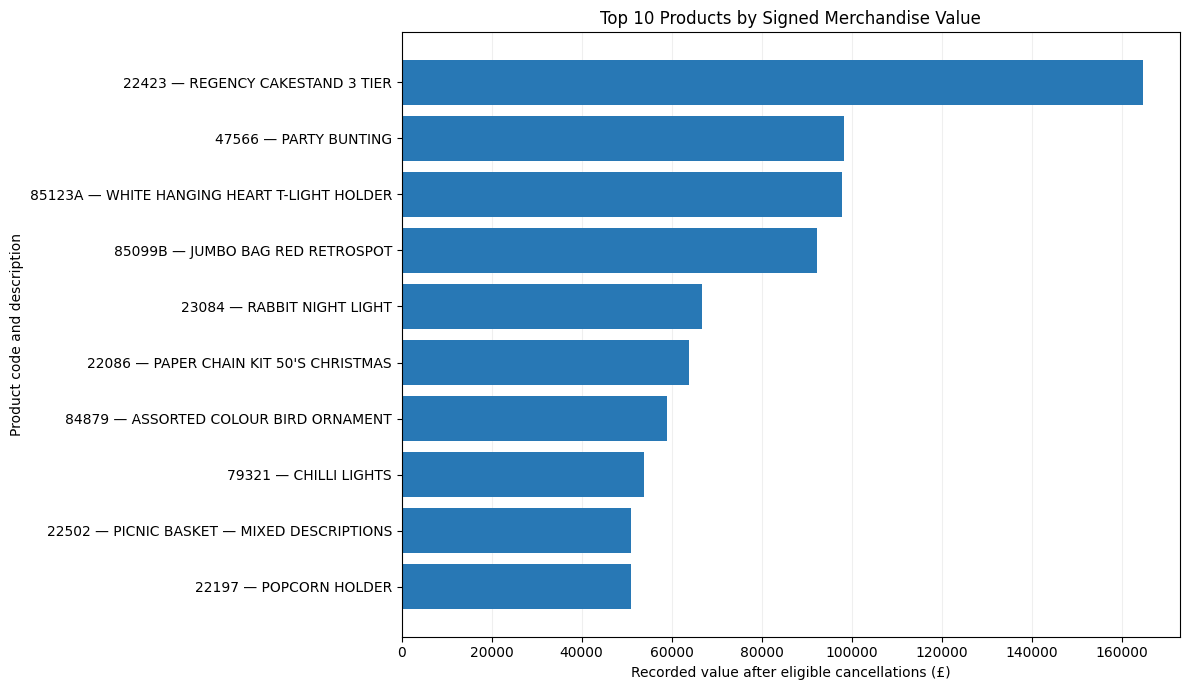

In [16]:
chart_products = top_products.sort_values("signed_value_gbp")

labels = (
    chart_products.index.astype(str)
    + " — "
    + chart_products["description_label"].str.slice(0, 38)
)

fig_products, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    labels,
    chart_products["signed_value_gbp"],
    color="#2878B5"
)

ax.set_title("Top 10 Products by Signed Merchandise Value")
ax.set_xlabel("Recorded value after eligible cancellations (£)")
ax.set_ylabel("Product code and description")
ax.ticklabel_format(axis="x", style="plain")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

fig_products.tight_layout()
plt.show()

In [ ]:
chart_filename = "03_top_products_signed_value.png"

fig_products.savefig(
    chart_filename,
    dpi=300,
    bbox_inches="tight"
)

files.download(chart_filename)

#### Follow-up: Picnic-Basket Product Code 22502

Inspect descriptions, prices, and large transactions associated
with this code. Assess how excluding its largest positive line
would affect its signed value and ranking.

This is an exploratory sensitivity test, not a decision to remove
the transaction.

In [17]:
basket_records = prepared_df.loc[
    prepared_df["StockCode"].eq("22502")
].copy()

print("1. RECORDS BY DESCRIPTION AND UNIT PRICE")
basket_description_summary = (
    basket_records
    .groupby(["Description", "UnitPrice"], dropna=False)
    .agg(
        line_count=("InvoiceNo", "size"),
        signed_recorded_value_gbp=("line_value", "sum")
    )
    .reset_index()
    .sort_values("line_count", ascending=False)
)

display(basket_description_summary.round(2))

print("\n2. LARGEST ABSOLUTE LINE VALUES")
basket_records["absolute_line_value"] = (
    basket_records["line_value"].abs()
)

display(
    basket_records.nlargest(10, "absolute_line_value")[
        [
            "InvoiceNo",
            "Description",
            "Quantity",
            "UnitPrice",
            "line_value",
            "CustomerID",
            "InvoiceDate",
            "is_cancellation"
        ]
    ]
)

1. RECORDS BY DESCRIPTION AND UNIT PRICE


,Description,UnitPrice,line_count,signed_recorded_value_gbp
4,PICNIC BASKET WICKER SMALL,5.95,219,4069.80
8,PICNIC BASKET WICKER SMALL,10.79,98,1618.50
5,PICNIC BASKET WICKER SMALL,8.29,96,1533.65
3,PICNIC BASKET WICKER SMALL,4.95,32,3455.10
6,PICNIC BASKET WICKER SMALL,8.47,29,474.32
10,NaN,0.00,4,0.00
0,PICNIC BASKET WICKER 60 PIECES,649.50,2,39619.50
2,PICNIC BASKET WICKER SMALL,2.00,1,2.00
1,PICNIC BASKET WICKER SMALL,0.00,1,0.00
7,PICNIC BASKET WICKER SMALL,8.95,1,268.50



2. LARGEST ABSOLUTE LINE VALUES


,InvoiceNo,Description,Quantity,UnitPrice,line_value,CustomerID,InvoiceDate,is_cancellation
222680,556444,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.0,15098,2011-06-10 15:28:00,False
222682,556446,PICNIC BASKET WICKER 60 PIECES,1,649.50,649.5,15098,2011-06-10 15:33:00,False
180755,552342,PICNIC BASKET WICKER SMALL,96,4.95,475.2,17949,2011-05-09 12:07:00,False
222670,556442,PICNIC BASKET WICKER SMALL,60,4.95,297.0,15098,2011-06-10 15:22:00,False
222692,C556448,PICNIC BASKET WICKER SMALL,-60,4.95,-297.0,15098,2011-06-10 15:39:00,True
116817,546306,PICNIC BASKET WICKER SMALL,30,8.95,268.5,<NA>,2011-03-10 16:16:00,False
71984,542222,PICNIC BASKET WICKER SMALL,48,4.95,237.6,14616,2011-01-26 12:42:00,False
116099,546212,PICNIC BASKET WICKER SMALL,48,4.95,237.6,14156,2011-03-10 11:33:00,False
176907,552038,PICNIC BASKET WICKER SMALL,48,4.95,237.6,14156,2011-05-06 08:08:00,False
5109,536844,PICNIC BASKET WICKER SMALL,32,4.95,158.4,14236,2010-12-02 18:49:00,False


In [18]:
# Find the largest eligible positive line for this product.
basket_positive_lines = positive_sales_df.loc[
    positive_sales_df["StockCode"].eq("22502")
]

largest_basket_index = (
    basket_positive_lines["line_value"].idxmax()
)

largest_basket_value = (
    basket_positive_lines.loc[largest_basket_index, "line_value"]
)

# Exclude only that line in a temporary comparison dataset.
basket_test_data = prepared_df.drop(index=largest_basket_index)

basket_test_summary = summarize_products(basket_test_data)

baseline_basket_value = product_summary.loc[
    "22502", "signed_value_gbp"
]

comparison = pd.DataFrame({
    "scenario": [
        "Baseline",
        "Without largest positive basket line"
    ],
    "signed_value_gbp": [
        baseline_basket_value,
        basket_test_summary.loc["22502", "signed_value_gbp"]
    ],
    "signed_value_rank": [
        product_summary.loc["22502", "signed_value_rank"],
        basket_test_summary.loc["22502", "signed_value_rank"]
    ]
})

print("3. PRODUCT SENSITIVITY")
display(comparison.round(2))

print("Largest positive line (£):", round(largest_basket_value, 2))
print(
    "Largest line as % of baseline product signed value:",
    round(100 * largest_basket_value / baseline_basket_value, 2)
)

3. PRODUCT SENSITIVITY


,scenario,signed_value_gbp,signed_value_rank
0,Baseline,51041.37,9
1,Without largest positive basket line,12071.37,168


Largest positive line (£): 38970.0
Largest line as % of baseline product signed value: 76.35


#### Follow-up Conclusion

Product code 22502 contains differing descriptions and prices.
Its largest positive line contributes 76.35% of its signed value.

Excluding this line reduces signed value from £51,041.37 to
£12,071.37 and changes its rank from 9th to 168th.

The record is retained because the available data does not establish
that it is erroneous. Product identity, pack size, and pricing require
business verification before an inventory recommendation is made.

In [19]:
# Change the display label only; totals and classifications stay unchanged.
product_summary.loc[
    "22502", "description_label"
] = "PICNIC BASKET — MIXED DESCRIPTIONS"

top_products = (
    product_summary
    .sort_values("signed_value_gbp", ascending=False)
    .head(10)
)

### Analysis 5: Country Contributions

Compare eligible positive merchandise value, cancellation magnitude,
signed merchandise value, and positive invoice counts by country.

Calculate each country's share of overall signed merchandise value.
Show leading non-UK countries separately for readability.

Country describes the customer's recorded country. These results
do not establish market size, profitability, or expansion potential.

In [20]:
country_sales = positive_sales_df.groupby(
    "Country", dropna=False
).agg(
    positive_lines=("InvoiceNo", "size"),
    positive_invoices=("InvoiceNo", "nunique"),
    identified_customers=("CustomerID", "nunique"),
    positive_value_gbp=("line_value", "sum")
)

country_cancellations = merchandise_cancellations_df.groupby(
    "Country", dropna=False
).agg(
    cancellation_magnitude_gbp=(
        "line_value", lambda values: -values.sum()
    )
)

country_summary = (
    country_sales
    .join(country_cancellations, how="outer")
    .fillna(0)
)

country_summary["signed_value_gbp"] = (
    country_summary["positive_value_gbp"]
    - country_summary["cancellation_magnitude_gbp"]
)

overall_signed_value = country_summary["signed_value_gbp"].sum()

country_summary["share_of_signed_value_percent"] = (
    100
    * country_summary["signed_value_gbp"]
    / overall_signed_value
)

count_columns = [
    "positive_lines",
    "positive_invoices",
    "identified_customers"
]

country_summary[count_columns] = (
    country_summary[count_columns].astype(int)
)

country_summary = country_summary.sort_values(
    "signed_value_gbp",
    ascending=False
)

print("TOP 10 COUNTRIES BY SIGNED MERCHANDISE VALUE")
display(country_summary.head(10).round(2))

non_uk_summary = country_summary.loc[
    country_summary.index != "United Kingdom"
]

print("\nTOP 10 NON-UK COUNTRIES")
display(non_uk_summary.head(10).round(2))

print("\nUK AND NON-UK SHARES")
uk_share = country_summary.loc[
    "United Kingdom", "share_of_signed_value_percent"
]

print("UK share of overall signed value (%):", round(uk_share, 2))
print(
    "Non-UK share of overall signed value (%):",
    round(
        100 * non_uk_summary["signed_value_gbp"].sum()
        / overall_signed_value,
        2
    )
)

print("\nRECONCILIATION CHECKS")
print("Positive lines:", country_summary["positive_lines"].sum())
print(
    "Positive merchandise value (£):",
    round(country_summary["positive_value_gbp"].sum(), 2)
)
print(
    "Cancellation magnitude (£):",
    round(country_summary["cancellation_magnitude_gbp"].sum(), 2)
)
print("Signed merchandise value (£):", round(overall_signed_value, 2))
print(
    "Sum of country signed-value shares (%):",
    round(country_summary["share_of_signed_value_percent"].sum(), 2)
)

TOP 10 COUNTRIES BY SIGNED MERCHANDISE VALUE


,positive_lines,positive_invoices,identified_customers,positive_value_gbp,cancellation_magnitude_gbp,signed_value_gbp,share_of_signed_value_percent
Country,,,,,,,
United Kingdom,484005,17901,3916,8747533.15,445843.38,8301689.77,84.77
Netherlands,2322,93,9,283889.34,409.80,283479.54,2.89
EIRE,7779,282,3,271164.30,11500.84,259663.46,2.65
Germany,8658,443,94,205569.89,4761.49,200808.40,2.05
France,8100,382,87,184582.74,2419.35,182163.39,1.86
Australia,1181,56,9,138171.31,1181.31,136990.00,1.40
Switzerland,1935,50,21,53087.90,582.55,52505.35,0.54
Spain,2422,88,30,55725.11,3959.91,51765.20,0.53
Belgium,1935,98,25,36927.34,264.38,36662.96,0.37



TOP 10 NON-UK COUNTRIES


,positive_lines,positive_invoices,identified_customers,positive_value_gbp,cancellation_magnitude_gbp,signed_value_gbp,share_of_signed_value_percent
Country,,,,,,,
Netherlands,2322,93,9,283889.34,409.80,283479.54,2.89
EIRE,7779,282,3,271164.30,11500.84,259663.46,2.65
Germany,8658,443,94,205569.89,4761.49,200808.40,2.05
France,8100,382,87,184582.74,2419.35,182163.39,1.86
Australia,1181,56,9,138171.31,1181.31,136990.00,1.40
Switzerland,1935,50,21,53087.90,582.55,52505.35,0.54
Spain,2422,88,30,55725.11,3959.91,51765.20,0.53
Belgium,1935,98,25,36927.34,264.38,36662.96,0.37
Japan,321,19,8,37416.37,1996.58,35419.79,0.36



UK AND NON-UK SHARES
UK share of overall signed value (%): 84.77
Non-UK share of overall signed value (%): 15.23

RECONCILIATION CHECKS
Positive lines: 527759
Positive merchandise value (£): 10271404.55
Cancellation magnitude (£): 478724.18
Signed merchandise value (£): 9792680.37
Sum of country signed-value shares (%): 100.0


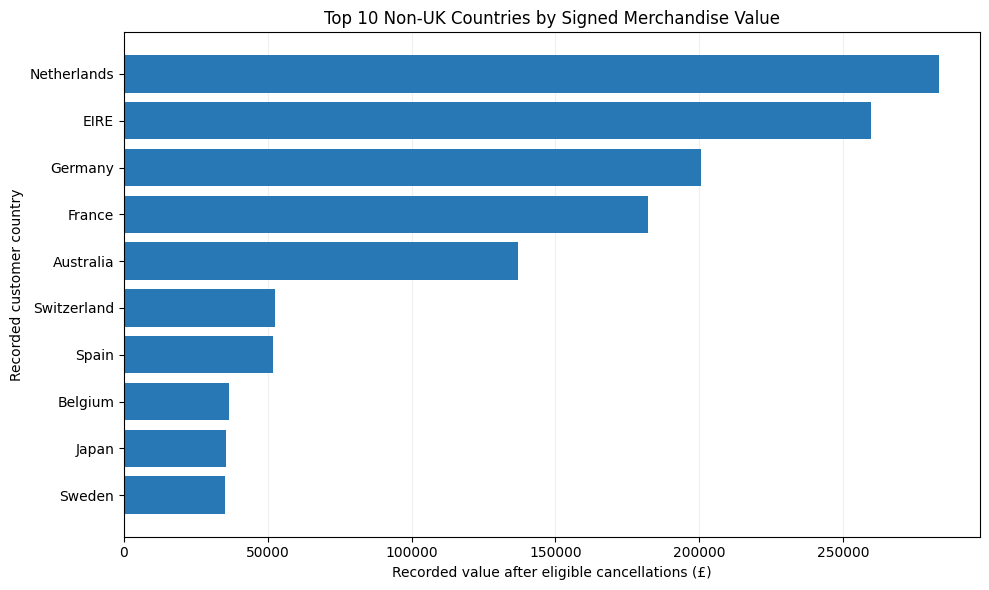

In [21]:
chart_countries = (
    non_uk_summary.head(10)
    .sort_values("signed_value_gbp")
)

fig_countries, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    chart_countries.index,
    chart_countries["signed_value_gbp"],
    color="#2878B5"
)

ax.set_title("Top 10 Non-UK Countries by Signed Merchandise Value")
ax.set_xlabel("Recorded value after eligible cancellations (£)")
ax.set_ylabel("Recorded customer country")
ax.ticklabel_format(axis="x", style="plain")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

fig_countries.tight_layout()
plt.show()

In [ ]:
chart_filename = "04_non_uk_country_value.png"

fig_countries.savefig(
    chart_filename,
    dpi=300,
    bbox_inches="tight"
)

files.download(chart_filename)

### Analysis 6: Repeat Purchasing and Customer Concentration

Analyze customers with recorded IDs and at least one eligible
positive merchandise invoice.

Define single-invoice purchasers as customers with one distinct
positive invoice and repeat purchasers as customers with two or more.

Report customer-ID coverage before interpreting results. Calculate
customer contributions using both positive and signed merchandise
value. Cancellation entries are attributed by recorded CustomerID,
without attempting to match each cancellation to a specific purchase.

Findings describe activity observed within this reporting window,
not lifetime purchasing behavior or a measured retention rate.

In [22]:
# Customer-level analysis uses eligible records with recorded IDs.
identified_cancellations = merchandise_cancellations_df.loc[
    ~merchandise_cancellations_df["missing_customer_id"]
].copy()

customer_summary = customer_sales_df.groupby("CustomerID").agg(
    positive_invoices=("InvoiceNo", "nunique"),
    positive_lines=("InvoiceNo", "size"),
    positive_value_gbp=("line_value", "sum"),
    first_positive_invoice=("InvoiceDate", "min"),
    last_positive_invoice=("InvoiceDate", "max")
)

customer_cancellations = (
    identified_cancellations.groupby("CustomerID")
    .agg(
        cancellation_magnitude_gbp=(
            "line_value", lambda values: -values.sum()
        )
    )
)

# Left join: the population is customers with positive merchandise activity.
customer_summary = customer_summary.join(
    customer_cancellations,
    how="left"
)

customer_summary["cancellation_magnitude_gbp"] = (
    customer_summary["cancellation_magnitude_gbp"].fillna(0)
)

customer_summary["signed_value_gbp"] = (
    customer_summary["positive_value_gbp"]
    - customer_summary["cancellation_magnitude_gbp"]
)

customer_summary["purchase_group"] = np.where(
    customer_summary["positive_invoices"].eq(1),
    "Single-invoice purchaser",
    "Repeat purchaser"
)

# Coverage uses the positive merchandise subset as its denominator.
identified_positive_value = customer_sales_df["line_value"].sum()
all_positive_value = positive_sales_df["line_value"].sum()

print("CUSTOMER-ID COVERAGE")
print("Positive lines with IDs:", len(customer_sales_df))
print(
    "Share of positive lines with IDs (%):",
    round(100 * len(customer_sales_df) / len(positive_sales_df), 2)
)
print(
    "Positive merchandise value with IDs (£):",
    round(identified_positive_value, 2)
)
print(
    "Share of positive merchandise value with IDs (%):",
    round(100 * identified_positive_value / all_positive_value, 2)
)

purchase_group_summary = customer_summary.groupby(
    "purchase_group"
).agg(
    customers=("positive_invoices", "size"),
    positive_invoices=("positive_invoices", "sum"),
    positive_value_gbp=("positive_value_gbp", "sum"),
    signed_value_gbp=("signed_value_gbp", "sum")
)

purchase_group_summary["share_of_customers_percent"] = (
    100 * purchase_group_summary["customers"] / len(customer_summary)
)

purchase_group_summary["share_of_signed_value_percent"] = (
    100 * purchase_group_summary["signed_value_gbp"]
    / customer_summary["signed_value_gbp"].sum()
)

purchase_group_summary = purchase_group_summary.reindex([
    "Single-invoice purchaser",
    "Repeat purchaser"
])

print("\nPURCHASING GROUPS")
display(purchase_group_summary.round(2))

top_customers = (
    customer_summary
    .sort_values("signed_value_gbp", ascending=False)
    .head(10)
)

print("\nTOP 10 CUSTOMERS BY SIGNED MERCHANDISE VALUE")
display(
    top_customers[
        [
            "positive_invoices",
            "positive_value_gbp",
            "cancellation_magnitude_gbp",
            "signed_value_gbp"
        ]
    ].round(2)
)

print(
    "\nTop 10 share of customer-cohort signed value (%):",
    round(
        100 * top_customers["signed_value_gbp"].sum()
        / customer_summary["signed_value_gbp"].sum(),
        2
    )
)

print("\nRECONCILIATION CHECKS")
print("Customers in cohort:", len(customer_summary))
print("Positive lines:", customer_summary["positive_lines"].sum())
print(
    "Positive value matches identified subset:",
    np.isclose(
        customer_summary["positive_value_gbp"].sum(),
        identified_positive_value
    )
)
print(
    "Customer-group shares total (%):",
    round(purchase_group_summary["share_of_customers_percent"].sum(), 2)
)
print(
    "Signed-value group shares total (%):",
    round(purchase_group_summary["share_of_signed_value_percent"].sum(), 2)
)

CUSTOMER-ID COVERAGE
Positive lines with IDs: 396340
Share of positive lines with IDs (%): 75.1
Positive merchandise value with IDs (£): 8761066.65
Share of positive merchandise value with IDs (%): 85.3

PURCHASING GROUPS


,customers,positive_invoices,positive_value_gbp,signed_value_gbp,share_of_customers_percent,share_of_signed_value_percent
purchase_group,,,,,,
Single-invoice purchaser,1505,1505,628969.67,538586.65,34.73,6.5
Repeat purchaser,2829,16897,8132096.98,7751999.65,65.27,93.5



TOP 10 CUSTOMERS BY SIGNED MERCHANDISE VALUE


,positive_invoices,positive_value_gbp,cancellation_magnitude_gbp,signed_value_gbp
CustomerID,,,,
14646,72,279138.02,360.00,278778.02
18102,60,259657.30,0.00,259657.30
17450,46,194550.79,4815.26,189735.53
14911,198,136275.72,7393.59,128882.13
12415,20,124564.53,926.35,123638.18
14156,54,116729.63,2874.31,113855.32
17511,31,91062.38,2924.18,88138.20
16684,28,66653.56,733.44,65920.12
13694,50,65039.62,2115.52,62924.10



Top 10 share of customer-cohort signed value (%): 16.54

RECONCILIATION CHECKS
Customers in cohort: 4334
Positive lines: 396340
Positive value matches identified subset: True
Customer-group shares total (%): 100.0
Signed-value group shares total (%): 100.0


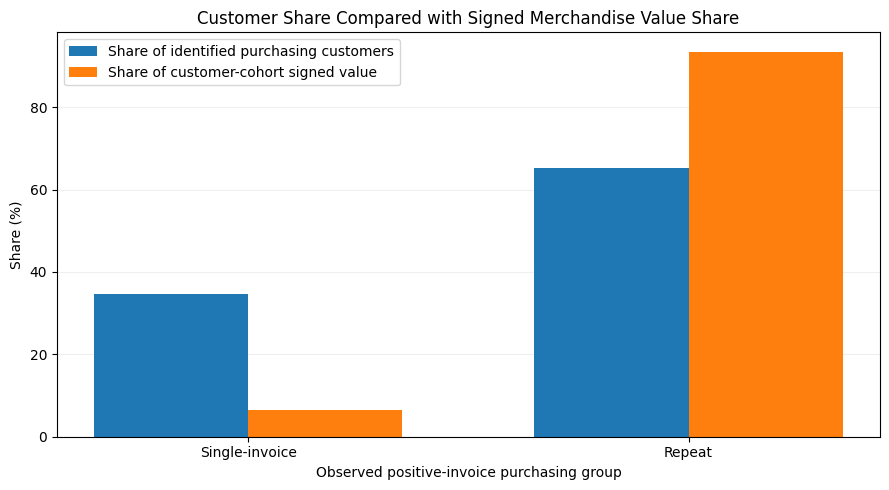

In [23]:
fig_customers, ax = plt.subplots(figsize=(9, 5))

positions = np.arange(len(purchase_group_summary))
bar_width = 0.35

ax.bar(
    positions - bar_width / 2,
    purchase_group_summary["share_of_customers_percent"],
    width=bar_width,
    label="Share of identified purchasing customers"
)

ax.bar(
    positions + bar_width / 2,
    purchase_group_summary["share_of_signed_value_percent"],
    width=bar_width,
    label="Share of customer-cohort signed value"
)

ax.set_xticks(positions)
ax.set_xticklabels(["Single-invoice", "Repeat"])
ax.set_ylabel("Share (%)")
ax.set_xlabel("Observed positive-invoice purchasing group")
ax.set_title("Customer Share Compared with Signed Merchandise Value Share")
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

fig_customers.tight_layout()
plt.show()

In [ ]:
chart_filename = "05_repeat_purchaser_contribution.png"

fig_customers.savefig(
    chart_filename,
    dpi=300,
    bbox_inches="tight"
)

files.download(chart_filename)

### Analysis 7: Cancellation Value and Large Reversal Cases

Calculate eligible merchandise cancellation magnitude as a percentage
of eligible positive merchandise value.

Compare baseline results with a scenario excluding the two large
positive transactions and their cancellation counterparts.

This value ratio does not measure the percentage of orders canceled.
Cancellation reasons and links to original orders are unavailable.

In [24]:
# Reuse the sensitivity summary from Analysis 2.
cancellation_comparison = sensitivity_summary.loc[
    sensitivity_summary["scenario"].isin([
        "Baseline",
        "Without large reversal cases"
    ]),
    [
        "scenario",
        "positive_lines",
        "cancellation_lines",
        "positive_value_gbp",
        "cancellation_magnitude_gbp",
        "signed_value_gbp"
    ]
].copy()

cancellation_comparison["cancellation_to_positive_value_percent"] = (
    100
    * cancellation_comparison["cancellation_magnitude_gbp"]
    / cancellation_comparison["positive_value_gbp"]
)

print("OVERALL CANCELLATION VALUE COMPARISON")
display(cancellation_comparison.round(2))

large_cancellation_magnitude = -(
    merchandise_cancellations_df.loc[
        merchandise_cancellations_df["is_large_reversal_case"],
        "line_value"
    ].sum()
)

all_cancellation_magnitude = -(
    merchandise_cancellations_df["line_value"].sum()
)

print(
    "\nLarge reversal cancellation magnitude (£):",
    round(large_cancellation_magnitude, 2)
)

print(
    "Large cases as share of cancellation magnitude (%):",
    round(
        100 * large_cancellation_magnitude
        / all_cancellation_magnitude,
        2
    )
)

OVERALL CANCELLATION VALUE COMPARISON


,scenario,positive_lines,cancellation_lines,positive_value_gbp,cancellation_magnitude_gbp,signed_value_gbp,cancellation_to_positive_value_percent
0,Baseline,527759,8704,10271404.55,478724.18,9792680.37,4.66
2,Without large reversal cases,527757,8702,10025751.35,233070.98,9792680.37,2.32



Large reversal cancellation magnitude (£): 245653.2
Large cases as share of cancellation magnitude (%): 51.31


In [25]:
# Start with the baseline monthly summary from Analysis 3.
monthly_cancellation_review = monthly_summary[
    ["positive_value_gbp", "cancellation_magnitude_gbp"]
].copy()

# Identify the value of the flagged large cases in each month.
large_positive_by_month = (
    positive_sales_df.loc[
        positive_sales_df["is_large_reversal_case"]
    ]
    .groupby(
        positive_sales_df.loc[
            positive_sales_df["is_large_reversal_case"],
            "InvoiceDate"
        ].dt.to_period("M")
    )["line_value"]
    .sum()
)

large_cancellation_by_month = (
    merchandise_cancellations_df.loc[
        merchandise_cancellations_df["is_large_reversal_case"]
    ]
    .groupby(
        merchandise_cancellations_df.loc[
            merchandise_cancellations_df["is_large_reversal_case"],
            "InvoiceDate"
        ].dt.to_period("M")
    )["line_value"]
    .sum()
    .mul(-1)
)

monthly_cancellation_review["large_positive_value_gbp"] = (
    large_positive_by_month
    .reindex(monthly_cancellation_review.index, fill_value=0)
)

monthly_cancellation_review["large_cancellation_magnitude_gbp"] = (
    large_cancellation_by_month
    .reindex(monthly_cancellation_review.index, fill_value=0)
)

monthly_cancellation_review["positive_value_without_large_gbp"] = (
    monthly_cancellation_review["positive_value_gbp"]
    - monthly_cancellation_review["large_positive_value_gbp"]
)

monthly_cancellation_review["cancellations_without_large_gbp"] = (
    monthly_cancellation_review["cancellation_magnitude_gbp"]
    - monthly_cancellation_review["large_cancellation_magnitude_gbp"]
)

monthly_cancellation_review["baseline_value_ratio_percent"] = (
    100
    * monthly_cancellation_review["cancellation_magnitude_gbp"]
    / monthly_cancellation_review["positive_value_gbp"]
)

monthly_cancellation_review["without_large_value_ratio_percent"] = (
    100
    * monthly_cancellation_review["cancellations_without_large_gbp"]
    / monthly_cancellation_review["positive_value_without_large_gbp"]
)

print("MONTHLY CANCELLATION VALUE RATIOS")
display(
    monthly_cancellation_review[
        [
            "cancellation_magnitude_gbp",
            "cancellations_without_large_gbp",
            "baseline_value_ratio_percent",
            "without_large_value_ratio_percent"
        ]
    ].round(2)
)

print("\nRECONCILIATION CHECKS")
print(
    "Baseline cancellation magnitude (£):",
    round(
        monthly_cancellation_review[
            "cancellation_magnitude_gbp"
        ].sum(),
        2
    )
)
print(
    "Cancellation magnitude without large cases (£):",
    round(
        monthly_cancellation_review[
            "cancellations_without_large_gbp"
        ].sum(),
        2
    )
)

MONTHLY CANCELLATION VALUE RATIOS


,cancellation_magnitude_gbp,cancellations_without_large_gbp,baseline_value_ratio_percent,without_large_value_ratio_percent
month,,,,
2010-12,17607.86,17607.86,2.26,2.26
2011-01,91526.30,14342.70,13.62,2.41
2011-02,8375.87,8375.87,1.65,1.65
2011-03,10675.30,10675.30,1.54,1.54
2011-04,33316.91,33316.91,6.45,6.45
2011-05,8948.23,8948.23,1.21,1.21
2011-06,13760.84,13760.84,1.86,1.86
2011-07,11409.21,11409.21,1.66,1.66
2011-08,22929.52,22929.52,3.16,3.16



RECONCILIATION CHECKS
Baseline cancellation magnitude (£): 478724.18
Cancellation magnitude without large cases (£): 233070.98


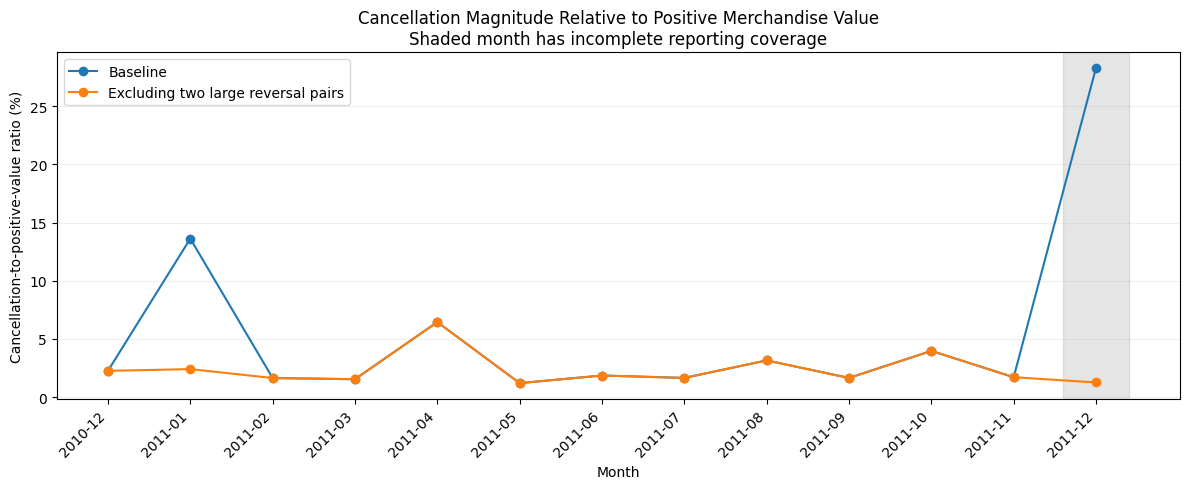

In [26]:
fig_cancellations, ax = plt.subplots(figsize=(12, 5))

positions = np.arange(len(monthly_cancellation_review))

ax.plot(
    positions,
    monthly_cancellation_review["baseline_value_ratio_percent"],
    marker="o",
    label="Baseline"
)

ax.plot(
    positions,
    monthly_cancellation_review["without_large_value_ratio_percent"],
    marker="o",
    label="Excluding two large reversal pairs"
)

for position, is_full_month in enumerate(
    monthly_summary["full_month_in_reporting_window"]
):
    if not is_full_month:
        ax.axvspan(
            position - 0.4,
            position + 0.4,
            color="gray",
            alpha=0.2
        )

ax.set_xticks(positions)
ax.set_xticklabels(
    monthly_cancellation_review.index.astype(str),
    rotation=45,
    ha="right"
)

ax.set_title(
    "Cancellation Magnitude Relative to Positive Merchandise Value\n"
    "Shaded month has incomplete reporting coverage"
)
ax.set_xlabel("Month")
ax.set_ylabel("Cancellation-to-positive-value ratio (%)")
ax.legend()
ax.grid(axis="y", alpha=0.2)

fig_cancellations.tight_layout()
plt.show()

In [ ]:
chart_filename = "06_cancellation_value_sensitivity.png"

fig_cancellations.savefig(
    chart_filename,
    dpi=300,
    bbox_inches="tight"
)

files.download(chart_filename)

## 5. Conclusions and Business Implications

### Reporting choices materially affect interpretation

Two large cancellation entries account for 51.31% of eligible
merchandise cancellation magnitude. Excluding their matching positive
and cancellation entries changes the cancellation-to-positive-value
ratio from 4.66% to 2.32%, while leaving signed merchandise value unchanged.

A separate picnic-basket investigation showed that excluding one
£38,970 line changes its product-code rank from 9th to 168th.
The differing descriptions and prices require business verification.

Recommendation: report positive value, cancellation magnitude, and
signed value separately, supported by documented exception reviews.

### Identified repeat purchasers contribute most customer-cohort value

Repeat purchasers represent 65.27% of identified purchasing customers
and contribute 93.50% of customer-cohort signed merchandise value.
The top 10 customers contribute 16.54%.

Recommendation: investigate purchasing recency, service needs,
cancellations, and margins before designing a targeted retention test.
Improve customer-ID capture.

These findings describe the identified purchasing cohort, not a
measured retention rate or demonstrated campaign effect.

### Merchandise value is geographically concentrated

The UK contributes 84.77% of overall signed merchandise value.
Netherlands and EIRE lead among non-UK countries.

Recommendation: investigate customer concentration and fulfillment
economics before making market-expansion decisions.

### Late-year activity warrants further investigation

Positive invoice counts and signed merchandise value increased from
September through November. November was the strongest complete month.

Recommendation: investigate contributing products and customers and
obtain additional years before assuming recurring seasonality.
December 2011 is incomplete.

## 6. Limitations

- Historical data from one retailer limits generalizability.
- Missing customer IDs restrict customer-level coverage.
- Exact repetitions remain included because their validity is unconfirmed.
- Merchandise classification follows documented analytical rules.
- Different product-code spellings remain separate.
- Product descriptions and prices may be inconsistent.
- Cancellation records are not systematically matched to original orders.
- Customers have different observation periods.
- Costs and margins are unavailable.
- The analysis is descriptive and does not demonstrate implemented
  business improvements.

## 7. Source and Reproducibility

Dataset: Online Retail
Creator: Daqing Chen
Provider: UCI Machine Learning Repository
Source: https://archive.ics.uci.edu/dataset/352/online+retail
License: CC BY 4.0
Citation: Chen, D. (2015). Online Retail [Dataset].
https://doi.org/10.24432/C5BW33

To reproduce:
1. Download and extract Online Retail.xlsx from the source.
2. Open this notebook in Google Colab.
3. Run the cells in order, uploading the Excel file when prompted.
4. Review the quality checks before interpreting the analysis outputs.

Processing changes are documented in this notebook. The original
records are preserved, with separate flags and analysis subsets.

In [27]:
# Check whether all eight tables exist in the current session.
required_tables = [
    "summary",
    "sensitivity_summary",
    "monthly_summary",
    "product_summary",
    "country_summary",
    "purchase_group_summary",
    "cancellation_comparison",
    "monthly_cancellation_review"
]

for name in required_tables:
    if name not in globals():
        print(f"{name}: MISSING")
    else:
        table = globals()[name]
        print(
            f"{name}: {type(table).__name__}; "
            f"CSV export supported: {hasattr(table, 'to_csv')}"
        )

summary: DataFrame; CSV export supported: True
sensitivity_summary: DataFrame; CSV export supported: True
monthly_summary: DataFrame; CSV export supported: True
product_summary: DataFrame; CSV export supported: True
country_summary: DataFrame; CSV export supported: True
purchase_group_summary: DataFrame; CSV export supported: True
cancellation_comparison: DataFrame; CSV export supported: True
monthly_cancellation_review: DataFrame; CSV export supported: True


In [30]:
from pathlib import Path
import shutil

export_folder = Path("online_retail_eda_summary_tables")
export_folder.mkdir(exist_ok=True)

# Export aggregate outputs rather than the full transaction dataset.
summary.to_csv(
    export_folder / "01_merchandise_baseline.csv",
    index=False
)

sensitivity_summary.to_csv(
    export_folder / "02_sensitivity_comparison.csv",
    index=False
)

monthly_summary.to_csv(
    export_folder / "03_monthly_merchandise.csv",
    index=True
)

product_summary.to_csv(
    export_folder / "04_product_summary.csv",
    index=True
)

country_summary.to_csv(
    export_folder / "05_country_summary.csv",
    index=True
)

purchase_group_summary.to_csv(
    export_folder / "06_purchasing_groups.csv",
    index=True
)

cancellation_comparison.to_csv(
    export_folder / "07_cancellation_comparison.csv",
    index=False
)

monthly_cancellation_review.to_csv(
    export_folder / "08_monthly_cancellation_sensitivity.csv",
    index=True
)

exported_files = sorted(export_folder.glob("*.csv"))

print("Summary tables exported:", len(exported_files))
for exported_file in exported_files:
    print(exported_file.name)

zip_path = shutil.make_archive(
    "online_retail_eda_summary_tables",
    "zip",
    root_dir=export_folder
)

print("ZIP created:", zip_path)

Summary tables exported: 8
01_merchandise_baseline.csv
02_sensitivity_comparison.csv
03_monthly_merchandise.csv
04_product_summary.csv
05_country_summary.csv
06_purchasing_groups.csv
07_cancellation_comparison.csv
08_monthly_cancellation_sensitivity.csv
ZIP created: /content/online_retail_eda_summary_tables.zip


In [31]:
# Final checks: confirm record preservation and aggregate reconciliation.

assert len(raw_df) == 541909
assert len(prepared_df) == len(raw_df)
assert len(positive_sales_df) == 527759
assert len(merchandise_cancellations_df) == 8704
assert len(customer_summary) == 4334

expected_totals = {
    "positive_value_gbp": 10271404.55,
    "cancellation_magnitude_gbp": 478724.18,
    "signed_value_gbp": 9792680.37
}

for table_name, table in {
    "Monthly": monthly_summary,
    "Product": product_summary,
    "Country": country_summary
}.items():

    for column, expected in expected_totals.items():
        assert np.isclose(
            table[column].sum(),
            expected,
            rtol=0,
            atol=0.01
        ), f"{table_name}: {column} does not reconcile"

assert np.isclose(
    customer_summary["positive_value_gbp"].sum(),
    customer_sales_df["line_value"].sum(),
    rtol=0,
    atol=0.01
)

assert product_summary.loc[
    "22502", "description_label"
] == "PICNIC BASKET — MIXED DESCRIPTIONS"

print("Final validation passed.")
print("Original records preserved.")
print("Monthly, product, and country totals reconcile.")
print("Customer positive value reconciles with its identified subset.")
print("Picnic-basket display label is correct.")

Final validation passed.
Original records preserved.
Monthly, product, and country totals reconcile.
Customer positive value reconciles with its identified subset.
Picnic-basket display label is correct.


In [1]:
print("Session is responding")

Session is responding
